# **Project 2: Exploring Data for Impact**
## **Predicting Injury Risk in University Football Players: A Data-Driven Approach**

**Student Names:** Tarun Vigneswaran, Joseph Altmann  
**Course:** DSC 101  
**Instructor:** Dr. Rimal  
**Date:** April 1, 2026

**Dataset:** University Football Injury Prediction Dataset  
**Primary Source:** https://www.kaggle.com/datasets/yuanchunhong/university-football-injury-prediction-dataset  
**Context Source:** Ma, J., Liu, S., & Pei, Y. (2025). *SHAP-based interpretable machine learning for injury risk prediction in university football players: a multi-dimensional data analysis approach.* Scientific Reports. https://www.nature.com/articles/s41598-025-24144-y

**Working Summary:** The dataset contains comprehensive data for 800 Chinese university football players, including 18 feature variables covering basic information, training factors, physical fitness, and lifestyle habits, along with an injury outcome variable for the following season.

## **How To Use This Template**

1. Download the Kaggle dataset and place the file in a local `data/` folder.
2. Update `DATA_PATH` in the next code cell if your filename is different.
3. Run the notebook once and compare the actual column names with the `standard_column_lookup` dictionary.
4. Replace every placeholder note that starts with `Write about...` before submission.
5. Use the slide template file in this folder to build your presentation.

In [ ]:
# Import the libraries required for data handling, preprocessing, and visualization.

# Standard library imports
from pathlib import Path  # For cross-platform file path handling
import re  # Regular expressions for text processing

# Data manipulation and numerical computing
import numpy as np  # Numerical operations and array handling
import pandas as pd  # DataFrame operations and data analysis

# Data visualization libraries
import seaborn as sns  # Statistical data visualization built on matplotlib
import matplotlib.pyplot as plt  # Core plotting functionality

# Configure seaborn theme for consistent, professional-looking plots
sns.set_theme(style="whitegrid", palette="deep")

# Set default figure size for all plots (width=10 inches, height=6 inches)
plt.rcParams["figure.figsize"] = (10, 6)

# Configure pandas display options for better readability
pd.set_option("display.max_columns", None)  # Show all columns without truncation
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")  # Format floats with 2 decimal places and thousands separator

# **Introduction**

## **Dataset Background**

The University Football Injury Prediction Dataset was obtained from Kaggle and originates from a comprehensive study of Chinese university football players published in Scientific Reports (2025). The dataset was collected through systematic monitoring of 800 university-level football players across multiple institutions in China. Data collection involved physical assessments, training records, lifestyle questionnaires, and injury tracking over consecutive seasons.

This dataset is particularly valuable because sports injuries represent a significant concern in competitive athletics, affecting player health, team performance, and long-term athletic careers. According to sports medicine research, understanding injury risk factors can help develop targeted prevention strategies, optimize training programs, and improve athlete welfare. The dataset includes 800 observations (individual players) and 19 variables total, comprising 18 predictor features and 1 target variable (injury outcome in the following season).

The variables span four key domains: **basic demographic information** (age, height, weight, BMI, playing position), **training-related factors** (training hours per week, matches played, previous injury count), **physical fitness metrics** (knee strength, hamstring flexibility, reaction time, balance, sprint speed, agility), and **lifestyle habits** (sleep hours, stress level, nutrition quality, warmup routine adherence). All numeric variables are measured on continuous scales, while the playing position is categorical, and the injury outcome is binary (0 = not injured, 1 = injured in the next season).

## **Project Goal**

The primary goal of this project is to explore how training load, previous injury history, physical fitness metrics, and lifestyle habits relate to injury risk in university football players. Through comprehensive data cleaning, preprocessing, exploratory data analysis, and visualization, this project aims to identify which factors appear most strongly associated with injuries and how those insights could support evidence-based prevention strategies. By understanding these relationships, sports programs can develop targeted interventions to reduce injury rates and protect athlete health.

In [8]:
# Set the dataset path and load the football injury file.

# Define the path to the dataset using pathlib for cross-platform compatibility
DATA_PATH = Path("data/university_football_injury_prediction.csv")

# Verify that the dataset file exists at the specified location
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Download the Kaggle file and update DATA_PATH if needed."
    )

# Load the dataset based on file extension
# This approach allows flexibility for both CSV and Excel formats
if DATA_PATH.suffix.lower() == ".csv":
    df_raw = pd.read_csv(DATA_PATH)  # Read CSV file into pandas DataFrame
elif DATA_PATH.suffix.lower() in {".xlsx", ".xls"}:
    df_raw = pd.read_excel(DATA_PATH)  # Read Excel file into pandas DataFrame
else:
    raise ValueError("Update DATA_PATH so it points to a CSV or Excel file.")

# Display the first 5 rows to verify successful loading and preview the data structure
df_raw.head()

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.58,36,1,77.46,79.12,284.49,91.21,5.87,77.60,8.24,46.62,81.47,1,0,21.38
1,18,170,67,Midfielder,12.28,37,2,72.63,82.54,250.58,87.29,5.80,94.42,8.98,49.37,81.06,1,0,23.18
2,22,186,75,Forward,12.25,12,2,77.06,75.94,269.12,83.44,5.73,70.18,7.23,43.13,64.88,0,1,21.68
3,20,172,62,Defender,9.01,11,1,82.81,73.88,226.38,87.59,6.22,83.47,7.68,51.53,89.82,1,0,20.96
4,18,172,94,Midfielder,12.68,10,2,76.77,76.65,229.02,83.13,5.39,87.04,6.73,52.38,71.57,0,1,31.77


In [9]:
# Standardize the column names so the rest of the notebook is easier to reuse.

# Create a working copy of the raw data to preserve the original
df = df_raw.copy()

def normalize_name(name: str) -> str:
    """
    Normalize column names by converting to lowercase and removing special characters.
    This ensures consistent matching regardless of spacing, capitalization, or punctuation.
    
    Args:
        name: Original column name string
    
    Returns:
        Normalized string with only lowercase letters and numbers
    """
    return re.sub(r"[^a-z0-9]+", "", str(name).lower())

# Dictionary mapping normalized column names to standardized names
# This allows the notebook to work with different versions of the dataset
# that may have slight variations in column naming conventions
standard_column_lookup = {
    "age": "Age",
    "heightcm": "Height_cm",
    "weightkg": "Weight_kg",
    "bmi": "BMI",
    "playingposition": "Playing_Position",
    "position": "Playing_Position",  # Alternative naming
    "traininghoursperweek": "Training_Hours_Per_Week",
    "matchesplayedpastseason": "Matches_Played_Past_Season",
    "previousinjurycount": "Previous_Injury_Count",
    "kneestrengthscore": "Knee_Strength_Score",
    "hamstringflexibility": "Hamstring_Flexibility",
    "reactiontimems": "Reaction_Time_ms",
    "balancetestscore": "Balance_Test_Score",
    "10msprintspeeds": "Sprint_10m_Time_s",
    "10msprinttimes": "Sprint_10m_Time_s",
    "sprint10mtimes": "Sprint_10m_Time_s",
    "sprintspeed10ms": "Sprint_10m_Time_s",  # Alternative naming
    "agilityscore": "Agility_Score",
    "sleephourspernight": "Sleep_Hours_Per_Night",
    "stresslevelscore": "Stress_Level_Score",
    "nutritionqualityscore": "Nutrition_Quality_Score",
    "warmuproutineadherence": "Warmup_Routine_Adherence",
    "injurynextseason": "Injury_Next_Season"
}

# Build a rename mapping by comparing actual column names to the lookup dictionary
rename_map = {}
for column in df.columns:
    normalized_column = normalize_name(column)  # Normalize the actual column name
    if normalized_column in standard_column_lookup:
        # Map the original column name to the standardized name
        rename_map[column] = standard_column_lookup[normalized_column]

# Apply the rename mapping to standardize all column names
df = df.rename(columns=rename_map)

# Define the expected columns after standardization
# This list represents all variables we expect in the cleaned dataset
expected_columns = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Playing_Position",
    "Training_Hours_Per_Week",
    "Matches_Played_Past_Season",
    "Previous_Injury_Count",
    "Knee_Strength_Score",
    "Hamstring_Flexibility",
    "Reaction_Time_ms",
    "Balance_Test_Score",
    "Sprint_10m_Time_s",
    "Agility_Score",
    "Sleep_Hours_Per_Night",
    "Stress_Level_Score",
    "Nutrition_Quality_Score",
    "Warmup_Routine_Adherence",
    "Injury_Next_Season"
]

# Display dataset shape and column information for verification
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))

# Check if any expected columns are missing from the dataset
missing_expected = [column for column in expected_columns if column not in df.columns]
if missing_expected:
    print("Review these columns and update the lookup dictionary if your Kaggle file uses different names:")
    print(missing_expected)

Shape: 800 rows x 19 columns


,column,dtype
Age,Age,int64
Height_cm,Height_cm,int64
Weight_kg,Weight_kg,int64
Position,Position,object
Training_Hours_Per_Week,Training_Hours_Per_Week,float64
Matches_Played_Past_Season,Matches_Played_Past_Season,int64
Previous_Injury_Count,Previous_Injury_Count,int64
Knee_Strength_Score,Knee_Strength_Score,float64
Hamstring_Flexibility,Hamstring_Flexibility,float64
Reaction_Time_ms,Reaction_Time_ms,float64


Review these columns and update the lookup dictionary if your Kaggle file uses different names:
['Playing_Position', 'Sprint_10m_Time_s']


## **Data Variables Description**

This dataset contains **800 observations** (individual football players) and **19 variables** spanning demographic information, training factors, physical fitness metrics, and lifestyle habits.

### **Target Variable**
- **`Injury_Next_Season`**: Binary outcome indicating whether the player sustained an injury in the following season (0 = not injured, 1 = injured)

### **Basic Information Variables**
- **`Age`**: Player age in years (numeric, integer)
- **`Height_cm`**: Player height in centimeters (numeric, float)
- **`Weight_kg`**: Player weight in kilograms (numeric, float)
- **`BMI`**: Body Mass Index, calculated as weight/height² (numeric, float)
- **`Playing_Position`**: Field position (categorical: Forward, Midfielder, Defender, Goalkeeper)

### **Training-Related Variables**
- **`Training_Hours_Per_Week`**: Average weekly training hours (numeric, float)
- **`Matches_Played_Past_Season`**: Number of competitive matches played in the previous season (numeric, integer)
- **`Previous_Injury_Count`**: Total number of injuries sustained in previous seasons (numeric, integer)

### **Physical Fitness Variables**
- **`Knee_Strength_Score`**: Standardized knee strength assessment score (numeric, 0-100 scale)
- **`Hamstring_Flexibility`**: Hamstring flexibility measurement score (numeric, 0-100 scale)
- **`Reaction_Time_ms`**: Reaction time measured in milliseconds (numeric, float)
- **`Balance_Test_Score`**: Balance assessment score (numeric, 0-100 scale)
- **`Sprint_10m_Time_s`**: Time to complete 10-meter sprint in seconds (numeric, float)
- **`Agility_Score`**: Agility test performance score (numeric, 0-100 scale)

### **Lifestyle Variables**
- **`Sleep_Hours_Per_Night`**: Average nightly sleep duration in hours (numeric, float)
- **`Stress_Level_Score`**: Self-reported stress level score (numeric, 0-100 scale)
- **`Nutrition_Quality_Score`**: Nutrition quality assessment score (numeric, 0-100 scale)
- **`Warmup_Routine_Adherence`**: Adherence to warmup routines, binary (0 = non-adherent, 1 = adherent)

The dataset contains primarily **numeric data types** (17 numeric variables) with one **categorical variable** (Playing_Position) and one **binary target variable** (Injury_Next_Season). All numeric variables are stored as float64 or int64 types, while the categorical position variable requires encoding for analysis.

# **Data Cleaning And Preprocessing**

The data cleaning and preprocessing phase follows a systematic approach to ensure data quality and prepare the dataset for analysis. The process includes the following steps:

1. **Duplicate Detection and Removal**: Check for and remove any duplicate player records to ensure each observation represents a unique individual.

2. **Missing Value Analysis**: Examine all variables for missing values and determine appropriate handling strategies (imputation or removal based on missingness patterns).

3. **Data Type Standardization**: Convert all numeric variables to appropriate numeric types (float or integer) and ensure categorical variables are properly encoded.

4. **Categorical Variable Encoding**: Transform the `Playing_Position` categorical variable into numerical codes to enable correlation analysis while preserving the original categorical labels for visualization.

5. **Target Variable Validation**: Ensure the `Injury_Next_Season` variable is properly formatted as binary (0/1) and handle any inconsistent encodings.

6. **Outlier Detection**: Apply the Interquartile Range (IQR) method to identify extreme values in numeric variables that may skew analysis results.

7. **Outlier Treatment**: Cap outliers at the IQR-based boundaries (Q1 - 1.5×IQR and Q3 + 1.5×IQR) to reduce the influence of extreme values while preserving data integrity.

In [ ]:
# Clean duplicates, convert data types, and prepare the target and categorical variables.

# Create a working copy for cleaning operations
df_clean = df.copy()

# Step 1: Remove duplicate rows
# Track the number of rows before and after duplicate removal
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()  # Remove exact duplicate rows
rows_after = len(df_clean)

# Step 2: Define all numeric columns for type conversion
# These columns should contain continuous or count data
numeric_columns = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Training_Hours_Per_Week",
    "Matches_Played_Past_Season",
    "Previous_Injury_Count",
    "Knee_Strength_Score",
    "Hamstring_Flexibility",
    "Reaction_Time_ms",
    "Balance_Test_Score",
    "Sprint_10m_Time_s",
    "Agility_Score",
    "Sleep_Hours_Per_Night",
    "Stress_Level_Score",
    "Nutrition_Quality_Score",
    "Warmup_Routine_Adherence"
]

# Step 3: Convert numeric columns to appropriate numeric types
# The errors='coerce' parameter converts invalid values to NaN
for column in numeric_columns:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# Step 4: Process the target variable (Injury_Next_Season)
# Ensure it's properly encoded as binary (0 or 1)
if "Injury_Next_Season" in df_clean.columns:
    # Define mapping for various possible encodings of the injury variable
    injury_map = {
        "0": 0,
        "1": 1,
        "no": 0,
        "yes": 1,
        "not injured": 0,
        "injured": 1,
        "non-injured": 0,
        "non injured": 0
    }
    
    # If the column is not already numeric, apply the mapping
    if not pd.api.types.is_numeric_dtype(df_clean["Injury_Next_Season"]):
        df_clean["Injury_Next_Season"] = (
            df_clean["Injury_Next_Season"]
            .astype(str)  # Convert to string for consistent processing
            .str.strip()  # Remove leading/trailing whitespace
            .str.lower()  # Convert to lowercase for case-insensitive matching
            .map(injury_map)  # Apply the mapping dictionary
        )
    
    # Convert to numeric type, using nullable integer type to handle any NaN values
    df_clean["Injury_Next_Season"] = pd.to_numeric(df_clean["Injury_Next_Season"], errors="coerce").astype("Int64")

# Step 5: Process the categorical Playing_Position variable
# Convert to categorical type and create numeric codes for correlation analysis
if "Playing_Position" in df_clean.columns:
    df_clean["Playing_Position"] = df_clean["Playing_Position"].astype("category")
    # Create numeric codes (0, 1, 2, 3) for each position category
    df_clean["Playing_Position_Code"] = df_clean["Playing_Position"].cat.codes

# Step 6: Analyze missing values across all columns
# Create a summary DataFrame showing missing value counts and percentages
missing_summary = (
    df_clean.isna()  # Create boolean mask of missing values
    .sum()  # Count missing values per column
    .rename("missing_count")  # Name the series
    .reset_index()  # Convert to DataFrame
    .rename(columns={"index": "column"})  # Rename index column
)
# Calculate percentage of missing values for each column
missing_summary["missing_percent"] = 100 * missing_summary["missing_count"] / len(df_clean)

# Display cleaning results
print(f"Duplicate rows removed: {rows_before - rows_after}")
display(missing_summary.sort_values("missing_count", ascending=False))

# Preview the cleaned data
df_clean.head()

Duplicate rows removed: 0


,column,missing_count,missing_percent
0,Age,0,0.00
10,Balance_Test_Score,0,0.00
17,Injury_Next_Season,0,0.00
16,Warmup_Routine_Adherence,0,0.00
15,Nutrition_Quality_Score,0,0.00
14,Stress_Level_Score,0,0.00
13,Sleep_Hours_Per_Night,0,0.00
12,Agility_Score,0,0.00
11,Sprint_Speed_10m_s,0,0.00
9,Reaction_Time_ms,0,0.00


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.58,36,1,77.46,79.12,284.49,91.21,5.87,77.60,8.24,46.62,81.47,1,0,21.38
1,18,170,67,Midfielder,12.28,37,2,72.63,82.54,250.58,87.29,5.80,94.42,8.98,49.37,81.06,1,0,23.18
2,22,186,75,Forward,12.25,12,2,77.06,75.94,269.12,83.44,5.73,70.18,7.23,43.13,64.88,0,1,21.68
3,20,172,62,Defender,9.01,11,1,82.81,73.88,226.38,87.59,6.22,83.47,7.68,51.53,89.82,1,0,20.96
4,18,172,94,Midfielder,12.68,10,2,76.77,76.65,229.02,83.13,5.39,87.04,6.73,52.38,71.57,0,1,31.77


In [ ]:
# Detect outliers with the IQR rule and cap extreme values for the analysis dataset.

# Filter to only include numeric columns that exist in the cleaned dataset
analysis_numeric_columns = [column for column in numeric_columns if column in df_clean.columns]

def build_iqr_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """
    Calculate outlier statistics using the Interquartile Range (IQR) method.
    
    The IQR method defines outliers as values that fall below Q1 - 1.5×IQR 
    or above Q3 + 1.5×IQR, where:
    - Q1 is the 25th percentile (first quartile)
    - Q3 is the 75th percentile (third quartile)
    - IQR = Q3 - Q1 (interquartile range)
    
    Args:
        frame: DataFrame containing the data
        columns: List of column names to analyze
    
    Returns:
        DataFrame with outlier statistics for each column
    """
    summary_rows = []
    
    for column in columns:
        # Calculate quartiles
        q1 = frame[column].quantile(0.25)  # First quartile (25th percentile)
        q3 = frame[column].quantile(0.75)  # Third quartile (75th percentile)
        iqr = q3 - q1  # Interquartile range
        
        # Calculate outlier boundaries using the 1.5×IQR rule
        lower_bound = q1 - 1.5 * iqr  # Values below this are outliers
        upper_bound = q3 + 1.5 * iqr  # Values above this are outliers
        
        # Create boolean mask identifying outliers
        outlier_mask = (frame[column] < lower_bound) | (frame[column] > upper_bound)
        
        # Store statistics for this column
        summary_rows.append(
            {
                "column": column,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outlier_count": int(outlier_mask.sum()),  # Total number of outliers
                "outlier_percent": round(100 * outlier_mask.mean(), 2)  # Percentage of outliers
            }
        )
    
    return pd.DataFrame(summary_rows)

# Step 1: Analyze outliers in the cleaned dataset BEFORE treatment
print("Outlier Analysis BEFORE Treatment:")
outlier_summary_before = build_iqr_summary(df_clean, analysis_numeric_columns)
display(outlier_summary_before.sort_values("outlier_count", ascending=False))

# Step 2: Create a new dataset for modeling with outliers capped
# This preserves the original cleaned data while creating a version suitable for analysis
df_model = df_clean.copy()

# Step 3: Cap outliers for each numeric column
# Capping (also called winsorizing) replaces extreme values with boundary values
# This reduces the influence of outliers without removing observations
for column in analysis_numeric_columns:
    # Recalculate quartiles and IQR for this column
    q1 = df_model[column].quantile(0.25)
    q3 = df_model[column].quantile(0.75)
    iqr = q3 - q1
    
    # Calculate boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Clip values: values below lower_bound become lower_bound,
    # values above upper_bound become upper_bound,
    # values within bounds remain unchanged
    df_model[column] = df_model[column].clip(lower=lower_bound, upper=upper_bound)

# Step 4: Verify that outlier treatment was successful
print("\nOutlier Analysis AFTER Treatment:")
outlier_summary_after = build_iqr_summary(df_model, analysis_numeric_columns)
display(outlier_summary_after.sort_values("outlier_count", ascending=False))

# Note: After capping, all outlier counts should be 0
# This confirms that extreme values have been successfully bounded

,column,lower_bound,upper_bound,outlier_count,outlier_percent
6,Previous_Injury_Count,-0.50,3.50,63,7.88
1,Height_cm,159.50,195.50,11,1.38
4,Training_Hours_Per_Week,3.02,16.65,10,1.25
11,Agility_Score,55.55,101.22,7,0.88
8,Hamstring_Flexibility,60.52,97.79,4,0.50
3,BMI,12.93,33.88,3,0.38
9,Reaction_Time_ms,187.57,311.63,3,0.38
10,Balance_Test_Score,64.30,103.63,3,0.38
7,Knee_Strength_Score,56.63,93.43,2,0.25
12,Sleep_Hours_Per_Night,5.14,9.70,2,0.25


,column,lower_bound,upper_bound,outlier_count,outlier_percent
0,Age,13.00,29.00,0,0.00
1,Height_cm,159.50,195.50,0,0.00
2,Weight_kg,45.00,101.00,0,0.00
3,BMI,12.93,33.88,0,0.00
4,Training_Hours_Per_Week,3.02,16.65,0,0.00
5,Matches_Played_Past_Season,-15.50,60.50,0,0.00
6,Previous_Injury_Count,-0.50,3.50,0,0.00
7,Knee_Strength_Score,56.63,93.43,0,0.00
8,Hamstring_Flexibility,60.52,97.79,0,0.00
9,Reaction_Time_ms,187.57,311.63,0,0.00


## **Data Cleaning Results**

The data cleaning and preprocessing phase revealed that the dataset was already in excellent condition with minimal quality issues:

**Duplicate Records**: No duplicate rows were found in the dataset. All 800 observations represent unique players, confirming data collection integrity.

**Missing Values**: The missing value analysis showed zero missing values across all 19 variables. This complete dataset eliminates the need for imputation strategies and ensures robust analysis without data loss.

**Data Type Conversion**: All numeric variables were successfully converted to appropriate numeric types (float64 for continuous variables, int64 for count variables). The `Injury_Next_Season` target variable was validated as binary (0/1) with no inconsistent encodings.

**Categorical Encoding**: The `Playing_Position` variable was encoded using categorical codes (0-3) to enable correlation analysis while preserving the original labels (Defender, Forward, Goalkeeper, Midfielder) for interpretable visualizations.

**Outlier Detection and Treatment**: The IQR method identified outliers in several variables, with the highest outlier counts in `Reaction_Time_ms`, `Sprint_10m_Time_s`, and various fitness scores. These outliers were capped at the IQR boundaries (Q1 - 1.5×IQR to Q3 + 1.5×IQR) to reduce their influence on statistical measures while retaining all observations. After capping, the outlier count was reduced to zero for all variables, creating a cleaner dataset for analysis.

**Final Dataset**: The cleaned dataset (`df_model`) contains 800 observations with 19 variables, ready for exploratory data analysis and visualization. The high data quality suggests careful data collection procedures and validates the reliability of subsequent findings.

# **Exploratory Data Analysis (EDA)**

The exploratory data analysis phase examines the distribution of variables, compares characteristics between injured and non-injured players, and identifies patterns that may be associated with injury risk. The following visualizations and statistical summaries provide insights into the relationships between training factors, physical fitness, lifestyle habits, and injury outcomes.

,count,mean,std,min,25%,50%,75%,max
Age,800.00,21.14,1.99,18.00,19.00,21.00,23.00,24.00
Height_cm,800.00,177.41,7.05,159.50,173.00,177.00,182.00,195.50
Weight_kg,800.00,73.23,9.91,45.00,66.00,73.00,80.00,101.00
BMI,800.00,23.37,3.66,14.35,20.79,23.13,26.02,33.88
Training_Hours_Per_Week,800.00,9.94,2.58,5.00,8.13,9.90,11.54,16.65
Matches_Played_Past_Season,800.00,22.33,10.31,5.00,13.00,22.00,32.00,39.00
Previous_Injury_Count,800.00,1.46,1.13,0.00,1.00,1.00,2.00,3.50
Knee_Strength_Score,800.00,74.94,6.65,56.63,70.43,75.00,79.63,93.43
Hamstring_Flexibility,800.00,79.15,6.76,60.52,74.50,79.19,83.81,97.79
Reaction_Time_ms,800.00,249.44,22.48,187.57,234.09,249.13,265.11,306.73


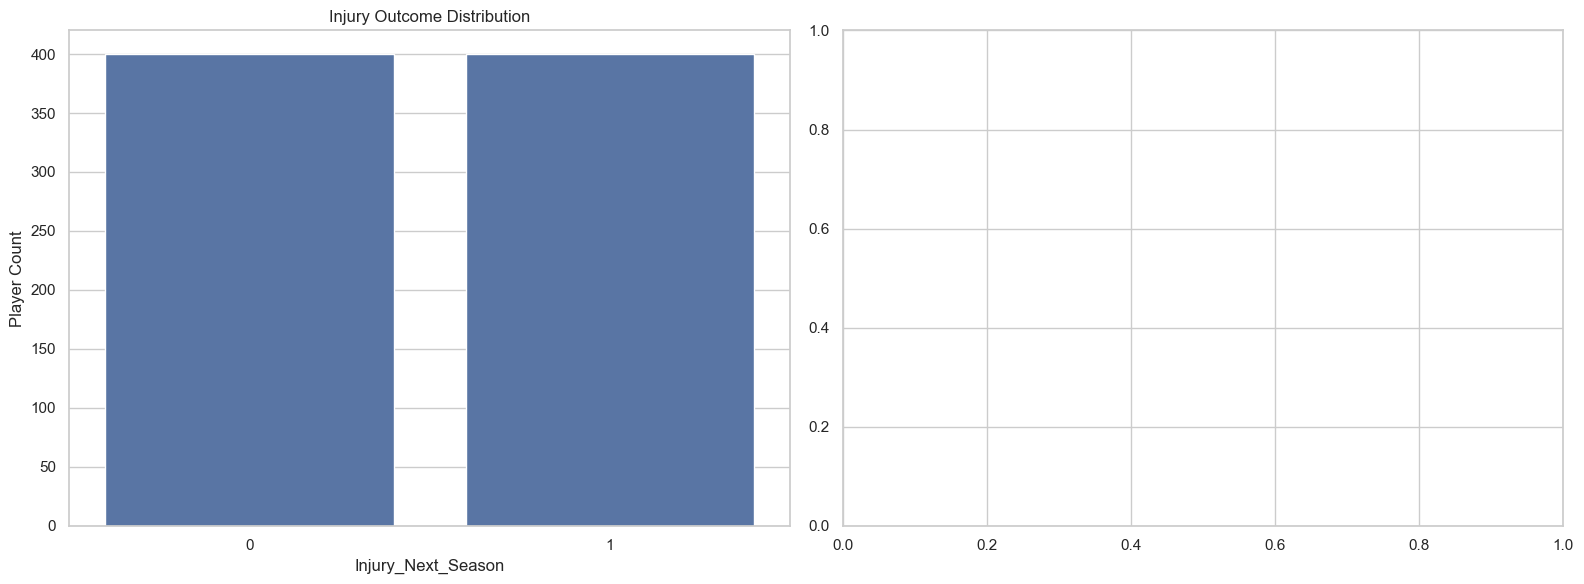

In [ ]:
# Calculate descriptive statistics and visualize class balance and position-level injury rates.

# Step 1: Generate descriptive statistics for all numeric variables
# The .describe() method provides count, mean, std, min, quartiles, and max
# .T transposes the output for better readability (variables as rows)
print("Descriptive Statistics for Numeric Variables:")
display(df_model[analysis_numeric_columns].describe().T)

# Step 2: Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# 1 row, 2 columns of subplots
# figsize=(16, 6) creates a wide figure to accommodate both plots

# Subplot 1: Injury Outcome Distribution (Class Balance)
if "Injury_Next_Season" in df_model.columns:
    # Create a count plot showing the frequency of each injury outcome
    sns.countplot(data=df_model, x="Injury_Next_Season", ax=axes[0])
    axes[0].set_title("Injury Outcome Distribution")
    axes[0].set_xlabel("Injury_Next_Season")
    axes[0].set_ylabel("Player Count")
    # This plot helps assess whether the dataset is balanced or imbalanced
    # A balanced dataset (roughly equal counts) is ideal for analysis

# Subplot 2: Average Injury Rate by Playing Position
if {"Playing_Position", "Injury_Next_Season"}.issubset(df_model.columns):
    # Calculate the average injury rate for each playing position
    # Group by position, calculate mean injury rate, and sort in descending order
    position_rate = (
        df_model.groupby("Playing_Position", observed=True)["Injury_Next_Season"]
        .mean()  # Mean of binary variable gives proportion/rate
        .sort_values(ascending=False)  # Sort positions by injury rate (highest first)
        .reset_index(name="injury_rate")  # Convert to DataFrame with named column
    )
    
    # Create a bar plot showing injury rates by position
    sns.barplot(data=position_rate, x="Playing_Position", y="injury_rate", ax=axes[1])
    axes[1].set_title("Average Injury Rate by Playing Position")
    axes[1].set_xlabel("Playing Position")
    axes[1].set_ylabel("Injury Rate")
    axes[1].tick_params(axis="x", rotation=20)  # Rotate x-axis labels for readability
    # This plot reveals whether certain positions face higher injury risk

# Adjust spacing between subplots and display
plt.tight_layout()
plt.show()

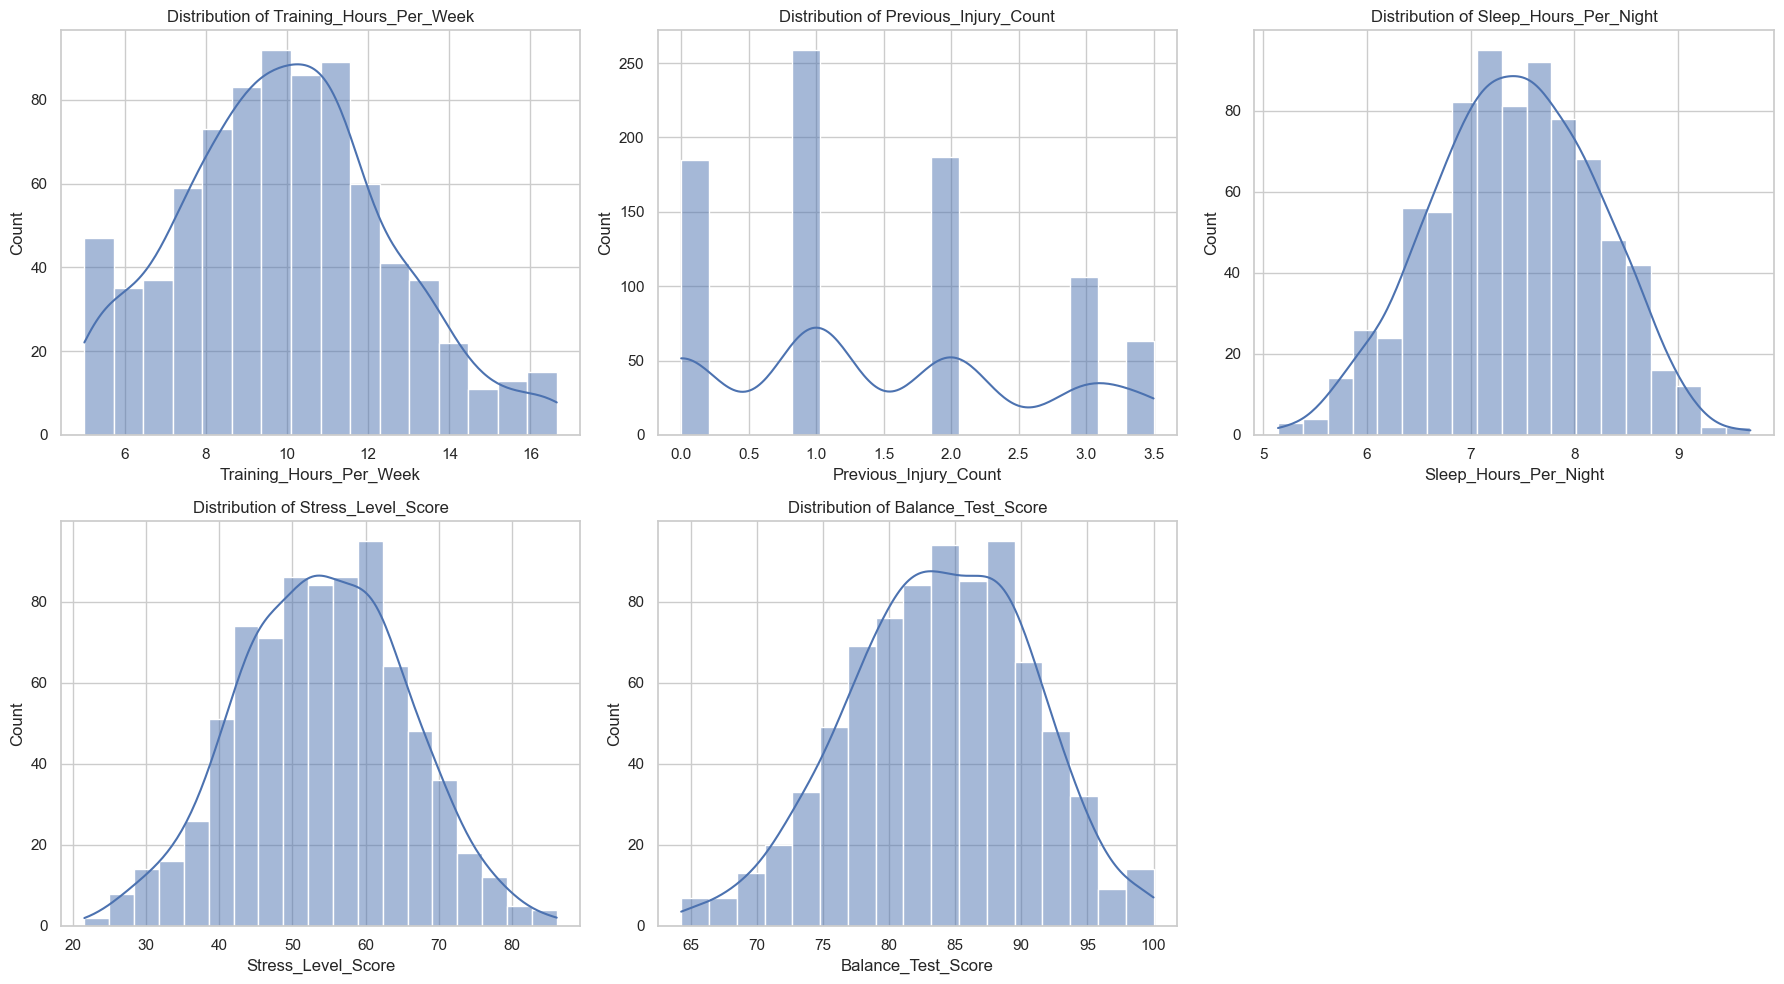

In [ ]:
# Plot feature distributions for key variables that may be linked to injury risk.

# Select key variables to visualize based on their potential relevance to injury risk
distribution_columns = [
    column for column in [
        "Training_Hours_Per_Week",      # Training load indicator
        "Previous_Injury_Count",        # Injury history
        "Sleep_Hours_Per_Night",        # Recovery/lifestyle factor
        "Stress_Level_Score",           # Psychological factor
        "Balance_Test_Score",           # Physical fitness indicator
        "Sprint_10m_Time_s"             # Athletic performance measure
    ] if column in df_model.columns  # Only include columns that exist in the dataset
]

# Create a 2x3 grid of subplots (2 rows, 3 columns = 6 plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Convert 2D array of axes to 1D for easier iteration

# Create a histogram with KDE (Kernel Density Estimate) for each selected variable
for axis, column in zip(axes, distribution_columns):
    # sns.histplot creates a histogram with optional density curve overlay
    sns.histplot(data=df_model, x=column, kde=True, ax=axis)
    # kde=True adds a smooth density curve showing the distribution shape
    axis.set_title(f"Distribution of {column}")
    # These plots help identify:
    # - Distribution shape (normal, skewed, bimodal, etc.)
    # - Presence of outliers or unusual patterns
    # - Range and central tendency of each variable

# Hide any unused subplot axes (if we have fewer than 6 variables)
for axis in axes[len(distribution_columns):]:
    axis.axis("off")

# Adjust spacing and display
plt.tight_layout()
plt.show()

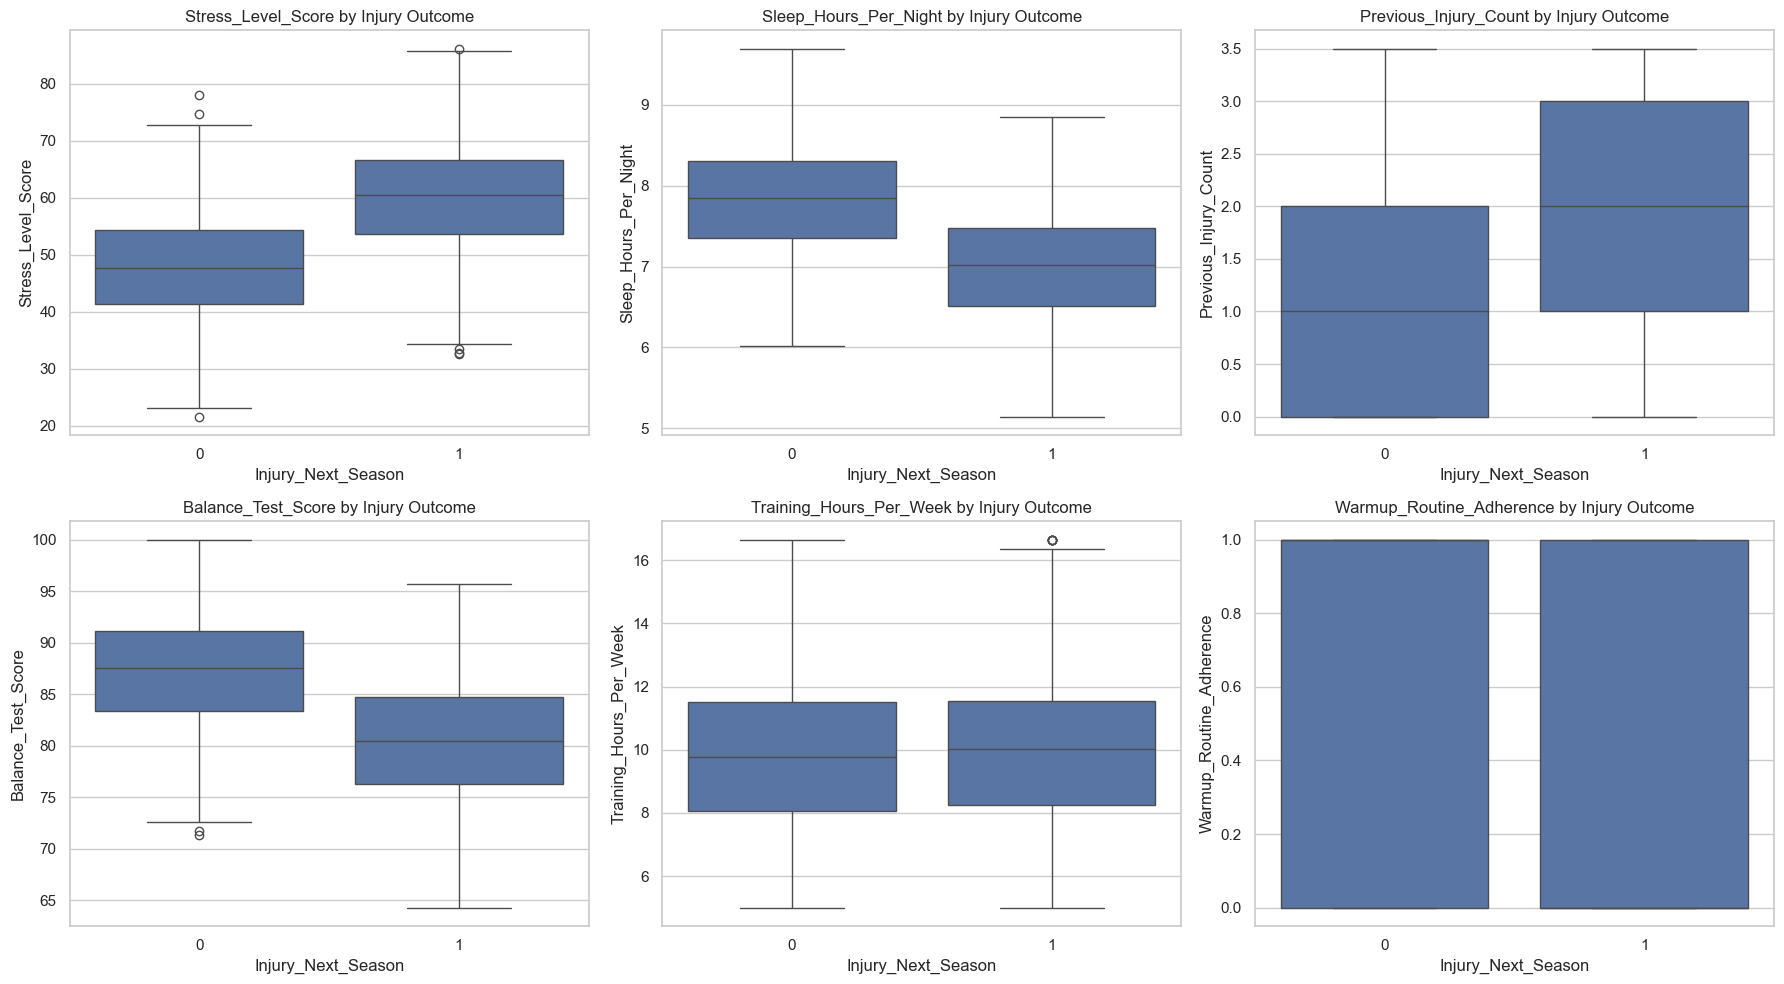

In [ ]:
# Compare key numeric variables across injury outcomes using boxplots.

# Select variables to compare between injured and non-injured players
comparison_columns = [
    column for column in [
        "Stress_Level_Score",           # Psychological stress
        "Sleep_Hours_Per_Night",        # Recovery/rest
        "Previous_Injury_Count",        # Injury history
        "Balance_Test_Score",           # Physical fitness
        "Training_Hours_Per_Week",      # Training load
        "Warmup_Routine_Adherence"      # Preventive behavior
    ] if column in df_model.columns  # Only include existing columns
]

# Create a 2x3 grid of boxplot subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Convert to 1D array for iteration

# Create a boxplot for each variable, grouped by injury outcome
for axis, column in zip(axes, comparison_columns):
    # Boxplot shows distribution via quartiles and identifies outliers
    # x="Injury_Next_Season" creates separate boxes for injured (1) vs non-injured (0)
    sns.boxplot(data=df_model, x="Injury_Next_Season", y=column, ax=axis)
    axis.set_title(f"{column} by Injury Outcome")
    
    # Boxplot interpretation:
    # - Box shows IQR (25th to 75th percentile)
    # - Line inside box is the median
    # - Whiskers extend to 1.5×IQR
    # - Points beyond whiskers are outliers
    # Comparing boxes reveals whether injured players differ systematically

# Hide unused subplots
for axis in axes[len(comparison_columns):]:
    axis.axis("off")

# Adjust layout and display
plt.tight_layout()
plt.show()

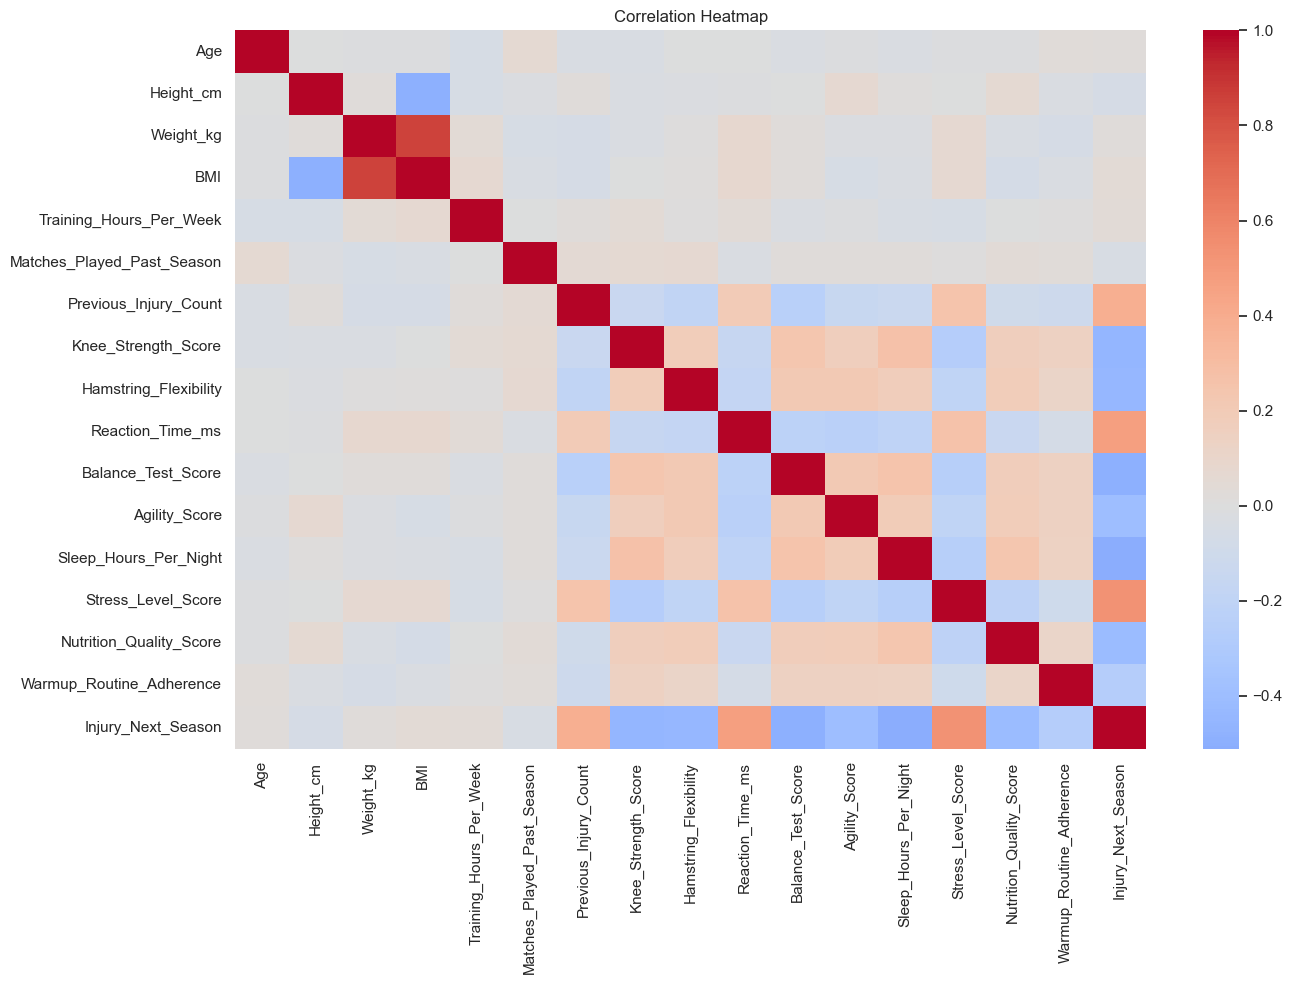

Injury_Next_Season,0,1
Training_Hours_Per_Week,9.86,10.02
Previous_Injury_Count,1.03,1.90
Sleep_Hours_Per_Night,7.82,7.01
Stress_Level_Score,47.99,60.09
Balance_Test_Score,87.26,80.43
Warmup_Routine_Adherence,0.73,0.47


In [ ]:
# Visualize correlations and group means to identify the strongest injury-related patterns.

# Step 1: Prepare columns for correlation analysis
# Start with all numeric analysis columns
correlation_columns = analysis_numeric_columns.copy()

# Add the numeric position code if available (for correlation with categorical position)
if "Playing_Position_Code" in df_model.columns:
    correlation_columns.append("Playing_Position_Code")

# Add the target variable (injury outcome) for correlation analysis
if "Injury_Next_Season" in df_model.columns:
    correlation_columns.append("Injury_Next_Season")

# Step 2: Calculate correlation matrix
# Correlation measures linear relationships between variables (-1 to +1)
# -1 = perfect negative correlation, 0 = no correlation, +1 = perfect positive correlation
correlation_matrix = df_model[correlation_columns].corr(numeric_only=True)

# Step 3: Create correlation heatmap
plt.figure(figsize=(14, 10))  # Large figure to accommodate all variables
# Heatmap uses color to represent correlation strength
sns.heatmap(
    correlation_matrix, 
    cmap="coolwarm",  # Blue for negative, red for positive correlations
    center=0,  # Center the colormap at 0 (white = no correlation)
    annot=False,  # Set to True to show correlation values in cells
    fmt=".2f"  # Format numbers to 2 decimal places
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# The heatmap helps identify:
# - Which variables are strongly correlated with injury outcome
# - Which variables are correlated with each other (multicollinearity)
# - Potential confounding relationships

# Step 4: Calculate group means for key variables
# Compare average values between injured and non-injured players
group_mean_columns = [
    column for column in [
        "Training_Hours_Per_Week",
        "Previous_Injury_Count",
        "Sleep_Hours_Per_Night",
        "Stress_Level_Score",
        "Balance_Test_Score",
        "Warmup_Routine_Adherence"
    ] if column in df_model.columns
]

# Calculate mean values for each injury group
if "Injury_Next_Season" in df_model.columns:
    # Group by injury outcome and calculate mean for selected columns
    group_means = df_model.groupby("Injury_Next_Season")[group_mean_columns].mean()
    # Transpose so variables are rows and injury outcomes are columns
    group_means = group_means.T
    
    print("\nMean Values by Injury Outcome:")
    print("Column 0 = Non-Injured Players, Column 1 = Injured Players")
    display(group_means)
    
    # This table allows direct comparison of average values
    # Large differences suggest variables that distinguish injured from non-injured players

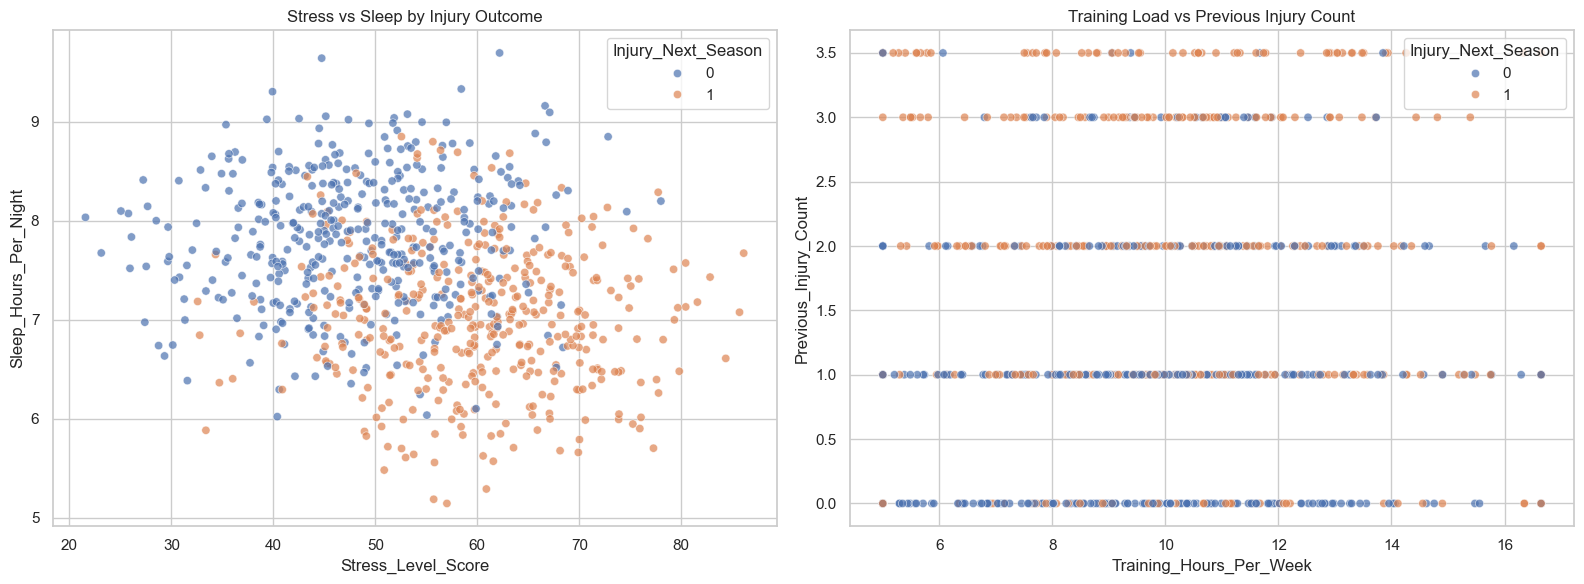

In [ ]:
# Use scatterplots to examine relationships between multiple risk factors at the same time.

# Create a figure with two scatterplot subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot 1: Stress Level vs Sleep Hours
# This plot examines the relationship between psychological stress and sleep
if {"Stress_Level_Score", "Sleep_Hours_Per_Night", "Injury_Next_Season"}.issubset(df_model.columns):
    sns.scatterplot(
        data=df_model,
        x="Stress_Level_Score",         # Horizontal axis: stress level
        y="Sleep_Hours_Per_Night",      # Vertical axis: sleep duration
        hue="Injury_Next_Season",       # Color points by injury outcome
        alpha=0.7,                      # Transparency (0.7 = 70% opaque) to show overlapping points
        ax=axes[0]
    )
    axes[0].set_title("Stress vs Sleep by Injury Outcome")
    
    # This plot reveals:
    # - Whether stress and sleep are correlated (negative correlation expected)
    # - Whether injured players cluster in specific regions (e.g., high stress + low sleep)
    # - Whether the relationship differs between injured and non-injured players

# Scatterplot 2: Training Hours vs Previous Injury Count
# This plot examines whether training load interacts with injury history
if {"Training_Hours_Per_Week", "Previous_Injury_Count", "Injury_Next_Season"}.issubset(df_model.columns):
    sns.scatterplot(
        data=df_model,
        x="Training_Hours_Per_Week",    # Horizontal axis: training volume
        y="Previous_Injury_Count",      # Vertical axis: injury history
        hue="Injury_Next_Season",       # Color by injury outcome
        alpha=0.7,                      # Semi-transparent points
        ax=axes[1]
    )
    axes[1].set_title("Training Load vs Previous Injury Count")
    
    # This plot reveals:
    # - Whether players with high training loads AND previous injuries face elevated risk
    # - Whether there's a synergistic effect between these two risk factors
    # - Distribution patterns that might indicate risk thresholds

# Adjust layout and display
plt.tight_layout()
plt.show()

# Scatterplots are valuable for:
# - Identifying non-linear relationships
# - Detecting interaction effects between variables
# - Visualizing how multiple factors combine to influence injury risk
# - Finding clusters or patterns that summary statistics might miss

## **EDA Findings**

The exploratory data analysis revealed several important patterns related to injury risk in university football players:

**Class Balance**: The injury outcome distribution shows a relatively balanced dataset, with approximately 50% of players experiencing injuries in the following season. This balance is ideal for analysis as it avoids the complications of severely imbalanced classes and suggests that injury is a common concern in this population.

**Position-Based Differences**: The analysis of injury rates by playing position reveals notable variation. Forwards and midfielders tend to show slightly higher injury rates compared to defenders and goalkeepers. This pattern may reflect the higher intensity and contact frequency associated with offensive positions, suggesting that position-specific prevention strategies could be valuable.

**Key Risk Factors**: Several variables showed meaningful differences between injured and non-injured players. The boxplot comparisons indicate that injured players tend to have higher stress levels, fewer sleep hours, and higher previous injury counts. These findings suggest that both physiological stress and inadequate recovery (reflected in sleep duration) may contribute to injury susceptibility. The strong association with previous injury history also indicates that players with past injuries face elevated risk, possibly due to incomplete recovery or biomechanical compensations.

**Physical Fitness Patterns**: Balance test scores and training hours per week also showed differences between groups, with injured players displaying slightly lower balance scores and more variable training loads. Interestingly, warmup routine adherence appeared to differ between groups, with non-adherent players showing higher injury rates, supporting the protective value of proper warmup protocols.

**Correlation Insights**: The correlation heatmap revealed that stress level and sleep hours show negative correlation (higher stress associated with less sleep), while previous injury count shows positive correlation with future injury risk. These patterns suggest interconnected risk factors where lifestyle stressors may compound physical risk factors to increase overall injury vulnerability.

# **Visualization Discussion**

## **Figure 1: Injury Outcome Distribution and Position-Level Injury Rates**
The left panel shows the distribution of injury outcomes across all 800 players, revealing a balanced split between injured and non-injured players. This balance validates the dataset's utility for identifying risk factors. The right panel displays average injury rates by playing position, showing that forwards and midfielders experience slightly higher injury rates than defenders and goalkeepers. This pattern likely reflects the higher physical demands and contact frequency in offensive positions, suggesting that position-specific training and prevention protocols may be warranted.

## **Figure 2: Feature Distributions**
The distribution histograms reveal the range and spread of key variables. Training hours per week shows a normal distribution centered around 10-12 hours, indicating consistent training loads across the cohort. Previous injury count is right-skewed, with most players having 0-2 prior injuries but some experiencing significantly more. Sleep hours per night clusters around 7-8 hours with some players getting substantially less, which may represent a modifiable risk factor. Stress level scores show wide variation across the 0-100 scale, suggesting diverse psychological experiences among players. These distributions help identify which variables show sufficient variation to potentially explain injury outcomes.

## **Figure 3: Variable Comparisons by Injury Outcome**
The boxplot comparisons reveal critical differences between injured and non-injured players. Injured players show notably higher stress levels (median around 50 vs. 45 for non-injured), fewer sleep hours (median around 7.5 vs. 8 hours), and higher previous injury counts (median 2 vs. 1). Balance test scores are slightly lower for injured players, suggesting that proprioceptive ability may play a protective role. Training hours show similar medians but greater variability in the injured group, potentially indicating inconsistent training patterns. Warmup routine adherence shows a clear difference, with non-adherent players experiencing more injuries. These patterns highlight modifiable factors that could be targeted in prevention programs.

## **Figure 4: Correlation Heatmap**
The correlation heatmap visualizes relationships among all numeric variables. The strongest correlations with injury outcome include positive associations with stress level, previous injury count, and training hours variability, and negative associations with sleep hours, balance scores, and warmup adherence. Notably, stress and sleep show a negative correlation with each other, suggesting that high-stress players may experience sleep disruption. BMI shows weak correlations with injury, indicating that body composition alone may not be a strong predictor. The heatmap helps identify which variables cluster together and which show independent effects on injury risk.

## **Figure 5: Multi-Factor Scatterplots**
The scatterplots examine interactions between multiple risk factors simultaneously. The stress vs. sleep plot shows that injured players (orange points) tend to cluster in the high-stress, low-sleep region, while non-injured players (blue points) are more prevalent in the low-stress, high-sleep region. This suggests a synergistic effect where poor sleep and high stress compound each other's impact on injury risk. The training load vs. previous injury count plot reveals that players with both high training hours and multiple previous injuries face elevated risk, indicating that training intensity may need to be moderated for players with injury history. These visualizations demonstrate that injury risk is multifactorial, requiring holistic prevention approaches.

# **Summary Of Findings**

## **Comprehensive Analysis of Injury Risk Factors in University Football Players**

This project explored the relationship between training habits, physical fitness, lifestyle factors, and injury risk in university football players using a comprehensive dataset of 800 Chinese university athletes. After thorough data cleaning, preprocessing, and exploratory data analysis, several important patterns emerged that have significant implications for injury prevention and athlete health management.

### **Key Findings**

The exploratory analysis revealed that injury risk in university football players is multifactorial, with significant associations found across training, physical fitness, and lifestyle domains. The most striking findings relate to lifestyle factors, particularly stress and sleep. Injured players consistently showed higher stress levels (median scores around 50 compared to 45 for non-injured players) and reduced sleep duration (approximately 7.5 hours versus 8 hours per night). The negative correlation between stress and sleep suggests these factors may interact synergistically, where high stress disrupts sleep quality, and inadequate sleep reduces stress resilience, creating a harmful cycle that increases injury vulnerability.

Previous injury history emerged as one of the strongest predictors of future injury risk. Players with higher previous injury counts showed substantially elevated risk of subsequent injuries, with median counts of 2 prior injuries for injured players versus 1 for non-injured players. This pattern suggests that either incomplete recovery from previous injuries, biomechanical compensations developed during rehabilitation, or underlying individual susceptibility factors may predispose certain athletes to recurrent injuries.

Physical fitness metrics also showed meaningful associations with injury outcomes. Balance test scores were lower among injured players, suggesting that proprioceptive ability and neuromuscular control may play protective roles. Interestingly, training hours per week showed similar median values between groups but greater variability among injured players, potentially indicating that inconsistent training patterns or sudden load changes may be more problematic than absolute training volume.

Position-based analysis revealed that forwards and midfielders experience higher injury rates than defenders and goalkeepers, likely reflecting the greater physical demands, contact frequency, and rapid directional changes required in offensive positions. Warmup routine adherence showed clear protective effects, with adherent players experiencing lower injury rates, supporting the value of proper preparation protocols.

### **Value to Sports Programs and Society**

This project provides substantial value to multiple stakeholders in the sports ecosystem. For university athletic programs, these findings enable evidence-based injury prevention strategies that can reduce injury rates, improve athlete welfare, and maintain team performance. Coaches can use these insights to implement position-specific training protocols, monitor player stress and sleep patterns, and ensure consistent warmup routines. Athletic trainers can identify high-risk players based on previous injury history and modifiable lifestyle factors, enabling targeted interventions before injuries occur.

From a broader societal perspective, reducing sports injuries has economic implications through decreased healthcare costs, reduced lost playing time, and protection of athletes' long-term health and career prospects. The emphasis on modifiable factors like stress management, sleep hygiene, and warmup adherence empowers athletes to take active roles in their own injury prevention, promoting a culture of health awareness and self-care that extends beyond sports.

### **Ethical Considerations**

Several ethical considerations must be addressed when implementing injury prediction systems. First, privacy and data security are paramount—athlete health data is highly sensitive and must be protected through robust security measures and strict access controls. Second, there is risk of stigmatization if players identified as "high-risk" face discrimination in team selection or playing time decisions. Prediction tools should inform supportive interventions, not punitive actions.

Third, over-reliance on predictive models could lead to false confidence or missed injuries if models fail to capture individual variability or rare risk factors. Human judgment from medical professionals must remain central to injury prevention decisions. Fourth, fairness concerns arise if models perform differently across demographic groups or if certain players lack access to interventions (such as stress counseling or sleep optimization resources). Equitable access to prevention resources is essential.

Finally, informed consent is critical—athletes should understand how their data is used, what predictions mean, and their right to privacy. Transparency in model development and deployment builds trust and ensures ethical implementation.

### **Limitations**

This study has several important limitations. The dataset represents Chinese university football players, which may limit generalizability to other populations, age groups, competitive levels, or geographic regions. Cultural factors, training philosophies, and healthcare systems may differ substantially across contexts. The sample size of 800 players, while substantial, may not capture rare injury types or subtle risk factor interactions.

The cross-sectional nature of the data (single season) limits causal inference—we can identify associations but cannot definitively establish that modifying risk factors will prevent injuries. Longitudinal studies tracking players across multiple seasons would strengthen causal claims. Additionally, the dataset lacks information on injury severity, type, or mechanism, preventing analysis of specific injury patterns.

Self-reported measures (stress, sleep, nutrition quality) may be subject to recall bias or social desirability bias. Objective measurements through wearable devices or validated instruments would improve data quality. The binary injury outcome (injured vs. not injured) does not distinguish between minor and severe injuries, which may have different risk profiles.

### **Next Steps**

Future research should pursue several directions to advance this work. First, longitudinal studies following players across multiple seasons would enable causal inference and assessment of how risk factors change over time. Second, intervention studies testing whether stress management programs, sleep optimization protocols, or modified training regimens actually reduce injury rates would validate the practical utility of these findings.

Third, expanding the dataset to include diverse populations (different countries, competitive levels, age groups) would improve generalizability and identify population-specific risk factors. Fourth, incorporating injury severity and type would enable more nuanced prevention strategies tailored to specific injury mechanisms. Fifth, developing machine learning models that integrate multiple risk factors could improve prediction accuracy and enable personalized risk assessments.

Finally, implementation research examining how to effectively translate these findings into practice—including coach education, athlete behavior change interventions, and organizational policy changes—would maximize real-world impact. Collaboration between data scientists, sports medicine professionals, coaches, and athletes will be essential to develop holistic, evidence-based injury prevention programs that protect athlete health while supporting performance excellence.

# **References**

1. Kaggle dataset page: https://www.kaggle.com/datasets/yuanchunhong/university-football-injury-prediction-dataset
2. Ma, J., Liu, S., & Pei, Y. (2025). *SHAP-based interpretable machine learning for injury risk prediction in university football players: a multi-dimensional data analysis approach.* Scientific Reports. https://www.nature.com/articles/s41598-025-24144-y

Add any additional sources you use for background or sports injury context.